# 01 - Vectors

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Make sure we get outputs from a probabilitistic model each time (for reproducibility)
np.random.seed(1515)

## What is a Vector?

A **vector** is just an ordered list of numbers. In this curriculum, you've already been handed vectors without the name: a tracked ball's velocity in `perception_primer/05-objects-in-motion.ipynb` was a pair of numbers $(v_x, v_y)$ - that *is* a vector. A 3D world point in `perception_primer/03-intrinsics-extrinsics.ipynb` was $(X, Y, Z)$ - also a vector.

A vector can represent two different kinds of things, depending on context:
- **A point** - a location in space, e.g. where a detected ball's bounding box center is.
- **A direction and magnitude** - e.g. velocity, which has both a heading (which way) and a speed (how fast).

Nothing about the vector itself tells you which one it is - that's context you bring, not something built into the numbers.

### Vector Addition and Scalar Multiplication

Recall from `perception_primer/05-objects-in-motion.ipynb`'s Ego vs. Object Motion section: $v_{\text{observed}} = v_{\text{object}} - v_{\text{camera}}$. That's **vector subtraction** - the same operation as addition, just with one vector flipped in sign first. Vector addition (and subtraction) works **component by component**: add the x-components together, add the y-components together, and so on. You don't need anything fancier than that.

**Scalar multiplication** means multiplying every component of a vector by the same single number (a **scalar**). You've seen this too: velocity times a time interval gives displacement ($\Delta x = v_x \cdot \Delta t$), which is exactly scalar multiplication applied to a velocity vector.

In [2]:
# Rearranging perception_primer's v_observed = v_object - v_camera to solve for v_object:
# v_object = v_observed + v_camera

v_observed = np.array([1200.0, 750.0])   # pixel velocity we measured for the ball (px/s)
v_camera = np.array([-300.0, 0.0])       # our own robot is drifting left at 300 px/s equiv.

v_object = v_observed + v_camera   # vector addition, component by component
print(f"v_observed: {v_observed}")
print(f"v_camera:   {v_camera}")
print(f"v_object:   {v_object}  (the ball's true field velocity)")

# Scalar multiplication: where does the ball end up in the next 0.5 seconds?
dt = 0.5
displacement = v_object * dt   # scaling the velocity vector by a scalar
print(f"\nDisplacement over {dt}s: {displacement}")

v_observed: [1200.  750.]
v_camera:   [-300.    0.]
v_object:   [900. 750.]  (the ball's true field velocity)

Displacement over 0.5s: [450. 375.]


Let's see that same addition happen visually - each vector drawn tip-to-tail, which is exactly what vector addition means geometrically.

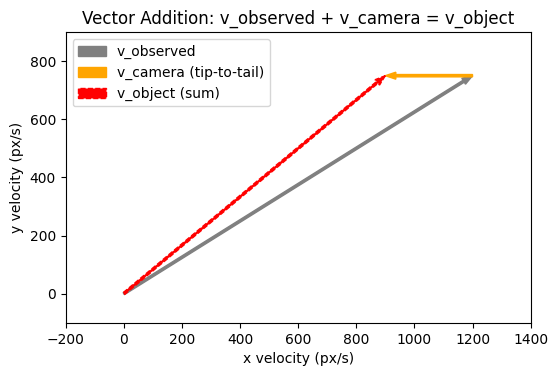

In [3]:
fig, ax = plt.subplots(figsize=(6, 6))

origin = np.array([0, 0])
ax.arrow(*origin, *v_observed, color='gray', width=8, length_includes_head=True, label='v_observed')
ax.arrow(*v_observed, *v_camera, color='orange', width=8, length_includes_head=True, label='v_camera (tip-to-tail)')
ax.arrow(*origin, *v_object, color='red', width=8, length_includes_head=True, linestyle='--', label='v_object (sum)')

ax.set_xlim(-200, 1400)
ax.set_ylim(-100, 900)
ax.set_xlabel('x velocity (px/s)')
ax.set_ylabel('y velocity (px/s)')
ax.set_title('Vector Addition: v_observed + v_camera = v_object')
ax.legend()
ax.set_aspect('equal')
plt.show()

Walking `v_observed`, then walking `v_camera` starting from where the first arrow ended, lands you in exactly the same place as walking `v_object` directly from the origin. That's the whole idea of vector addition - and it's the reason the ego-motion correction in `perception_primer/05` works at all: it's just this picture, run in reverse.

### Dot Product

The **dot product** of two vectors is a single number, computed by multiplying matching components together and summing the results:

$$ a \cdot b = a_1 b_1 + a_2 b_2 + \dots + a_n b_n $$

Geometrically, the dot product measures **how much two vectors point in the same direction**:
- A large positive dot product means the vectors point roughly the same way.
- A dot product near zero means the vectors are roughly perpendicular (unrelated directions).
- A negative dot product means the vectors point roughly opposite ways.

For a scouting-relevant example: if we know our own robot's heading vector, the dot product with an opponent's velocity vector tells us whether they're closing in on our path or crossing it harmlessly.

In [4]:
our_heading = np.array([1.0, 0.0])       # our robot is driving in the +x direction
opponent_closing = np.array([0.8, 0.1])  # opponent moving mostly toward/along our path
opponent_crossing = np.array([0.0, 1.0]) # opponent moving perpendicular to our path

dot_closing = np.dot(our_heading, opponent_closing)
dot_crossing = np.dot(our_heading, opponent_crossing)

print(f"Dot product (closing-in opponent):  {dot_closing:.2f}")
print(f"Dot product (crossing opponent):    {dot_crossing:.2f}")

Dot product (closing-in opponent):  0.80
Dot product (crossing opponent):    0.00


The closing-in opponent gives a clearly positive dot product with our heading; the crossing opponent gives (almost exactly) zero - confirming it's moving perpendicular to us, not toward us.

### Magnitude (Norm) and Distance

A vector's **magnitude** (also called its **norm**, written $\|v\|$) is its length - how far it reaches from the origin. It's computed by taking the dot product of a vector with itself, then taking the square root:

$$ \|v\| = \sqrt{v \cdot v} = \sqrt{v_1^2 + v_2^2 + \dots + v_n^2} $$

A **unit vector** is a vector with magnitude exactly 1 - you get one by dividing a vector by its own magnitude, which keeps the direction but strips out the length.

The **Euclidean distance** between two points is just the magnitude of the vector connecting them - subtract one point from the other, then take the magnitude of the result. This is exactly the `np.linalg.norm(...)` line from `perception_primer/05`'s Hungarian Algorithm section, computing the cost between every predicted and detected box center.

In [5]:
predicted_center = np.array([100.0, 100.0])
detected_center = np.array([105.0, 108.0])

# magnitude, computed by hand from the dot-product definition
v = predicted_center - detected_center
magnitude_by_hand = np.sqrt(np.dot(v, v))

# the same thing, the way perception_primer/05 actually wrote it
distance_via_norm = np.linalg.norm(predicted_center - detected_center)

print(f"Magnitude computed by hand:      {magnitude_by_hand:.2f}")
print(f"np.linalg.norm (same result):    {distance_via_norm:.2f}")

unit_v = v / np.linalg.norm(v)
print(f"\nUnit vector (direction only):    {unit_v}, magnitude = {np.linalg.norm(unit_v):.2f}")

Magnitude computed by hand:      9.43
np.linalg.norm (same result):    9.43

Unit vector (direction only):    [-0.52999894 -0.8479983 ], magnitude = 1.00


Now you know exactly what that one-line cost-matrix computation in the Hungarian Algorithm section was doing: turning a pair of 2D points into a single number - a distance - by treating their difference as a vector and taking its magnitude.

## Try It Yourself

A scouted opponent's pixel velocity (as measured by our camera) is `v_observed = np.array([-400.0, 200.0])`. Our own robot's camera-frame velocity equivalent is `v_camera = np.array([500.0, 0.0])`.

1. Compute the opponent's true field velocity `v_object` (vector addition, as above).
2. Compute the opponent's speed - the magnitude of `v_object`.
3. Our robot's own heading vector is `our_heading = np.array([1.0, 0.0])`. Compute the dot product of `our_heading` with the opponent's `v_object`, and use its sign to decide: is the opponent generally closing in on our heading, or moving away from/across it?

In [6]:
# TODO: 1. compute v_object = v_observed + v_camera

# TODO: 2. compute the magnitude (speed) of v_object

# TODO: 3. compute the dot product of our_heading and v_object, and interpret the sign


## Resources

- [3Blue1Brown: Essence of Linear Algebra - Vectors](https://www.3blue1brown.com/topics/linear-algebra) - the visual intuition this notebook builds on, chapters 1-3 especially (video series).
- [Khan Academy: Vectors](https://www.khanacademy.org/math/linear-algebra/vectors-and-spaces) - a slower-paced, exercise-heavy alternative if you want more practice (instructional).
- [NumPy: `numpy.dot` documentation](https://numpy.org/doc/stable/reference/generated/numpy.dot.html) - the function used above (reference).
- [NumPy: `numpy.linalg.norm` documentation](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html) - the function used above for magnitude/distance (reference).